# Database index performance

Plot recorded latency versus recall@10. Preserve the original exclusion of “Flat (brute-force)” and retain “No Index (baseline).”
This notebook does not run benchmarks or build indexes.


In [1]:
import sys
from pathlib import Path

ROOT = next(
    p
    for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "backend/app/configs/config.yaml").is_file()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import matplotlib.pyplot as plt
from analyses.publication import export_figure, load_settings, publication_style

settings = load_settings(ROOT)
publication_style()

In [3]:
import seaborn as sns
from analyses.publication import benchmark_data

benchmark = benchmark_data(ROOT)

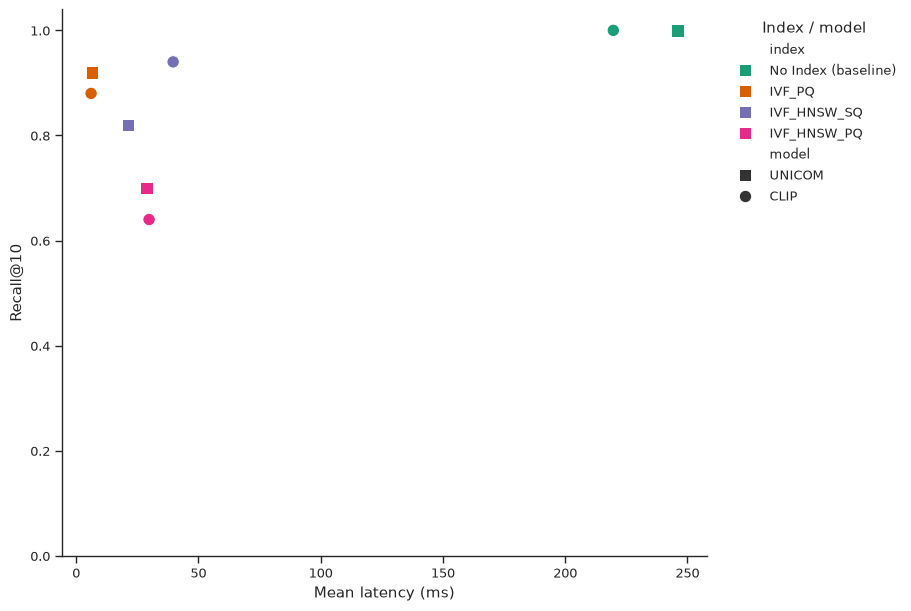

In [4]:
fig, ax = plt.subplots(figsize=(9, 6), layout="constrained")
sns.scatterplot(
    data=benchmark,
    x="avg_ms",
    y="recall@10",
    hue="index",
    style="model",
    markers={"UNICOM": "s", "CLIP": "o"},
    s=80,
    ax=ax,
)
ax.set(xlabel="Mean latency (ms)", ylabel="Recall@10", ylim=(0, 1.04))
ax.legend(title="Index / model", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
sns.despine(ax=ax)
export_figure(fig, settings, "indexing_benchmark", {"measurements": benchmark})
plt.show()
plt.close(fig)